Library & Module

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.ensemble import AdaBoostClassifier

from sklearn.ensemble import VotingClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report

1. Loading & Merge data
- CS: Control, labeled 1 (17개)
- DS: Diabetes, labelded -1 (13개)
- descriptive features: HF_peak, LF_peak, VLF_peak, HF_power, LF_power, VLF_power (6개)
- target feature: 1 / -1 (label, 1개)

In [2]:
# CSV 파일 불러오기
df_CS = pd.read_csv("/home/ibom-meca/2025.Jan_Feb.JeongHo_SEO/Diabetes_diagnosis_ML_model/Final_presentation/data/Original_labeled_data/ECG_data_CS.csv", header=None)
df_DS = pd.read_csv("/home/ibom-meca/2025.Jan_Feb.JeongHo_SEO/Diabetes_diagnosis_ML_model/Final_presentation/data/Original_labeled_data/ECG_data_DS.csv", header=None)

# 두 데이터 합치기
df = pd.concat([df_CS, df_DS], axis=0).reset_index(drop=True)

# X, y 분리
X = df.iloc[:, :-1].values  # Attribute (6개)
y = df.iloc[:, -1].values   # Label (1 or -1)

2. Stratified K-Fold (Cross-Validation)
- random_state: shuffle로 데이터를 섞을 때 다른 환경에서도 동일한 결과를 보장하기 위해, 정수값 사용. (42는 관례적인 선택일 뿐)

In [3]:
# Stratified K-Fold 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # k = 5

# K-Fold를 나누어 train, test index 구하기
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # K-Fold마다 분리된 데이터 확인
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 24, Test size: 6
Train size: 24, Test size: 6
Train size: 24, Test size: 6
Train size: 24, Test size: 6
Train size: 24, Test size: 6


3. Logistic Regression
- max_iteration: 모델이 수렴할 수 있는 충분한 반복 횟수를 주기 위해 max_iter를 늘리기. (default = 100)

In [4]:
# 로지스틱 회귀 모델 정의 (max_iter 증가)
logreg = LogisticRegression(max_iter=1000, random_state=42)

# 모델 학습
logreg.fit(X_train, y_train)

# 예측
y_train_logreg = logreg.predict(X_train) # training dataset
y_pred_logreg = logreg.predict(X_test) # testing dataset

# 정확도 평가
logreg_accuracy_train = accuracy_score(y_train, y_train_logreg) # train accuracy
logreg_accuracy_valid = accuracy_score(y_test, y_pred_logreg) # validation accuracy

print(f"Logistic Regression Train Accuracy: {logreg_accuracy_train:.4f}")
print(f"Logistic Regression Validation Accuracy: {logreg_accuracy_valid:.4f}")

Logistic Regression Train Accuracy: 0.6667
Logistic Regression Validation Accuracy: 0.5000


4. SVM

In [5]:
# SVM 모델 정의
svm = SVC(probability=True, random_state=42)

# 모델 학습
svm.fit(X_train, y_train)

# 예측
y_train_svm = svm.predict(X_train) # training dataset
y_pred_svm = svm.predict(X_test) # testing dataset

# 정확도 평가
svm_accuracy_train = accuracy_score(y_train, y_train_svm) # train accuracy
svm_accuracy_valid = accuracy_score(y_test, y_pred_svm) # validation accuracy

print(f"SVM Train Accuracy: {svm_accuracy_train:.4f}")
print(f"SVM Validation Accuracy: {svm_accuracy_valid:.4f}")

SVM Train Accuracy: 0.6250
SVM Validation Accuracy: 0.5000


5. Random Forest: Bagging in Ensemble

In [6]:
# 랜덤 포레스트 모델 정의
rf = RandomForestClassifier(random_state=42)

# 모델 학습
rf.fit(X_train, y_train)

# 예측
y_train_rf = rf.predict(X_train) # training dataset
y_pred_rf = rf.predict(X_test) # testing dataset

# 정확도 평가
rf_accuracy_train = accuracy_score(y_train, y_train_rf) # train accuracy
rf_accuracy_valid = accuracy_score(y_test, y_pred_rf) # validation accuracy

print(f"Random Forest Train Accuracy: {rf_accuracy_train:.4f}")
print(f"Random Forest Validation Accuracy: {rf_accuracy_valid:.4f}")

Random Forest Train Accuracy: 1.0000
Random Forest Validation Accuracy: 0.6667


6. Gradient Tree Boosting: Boosting in Ensemble

In [7]:
# Gradient Boosting 모델 정의
gb = GradientBoostingClassifier(random_state=42)

# 모델 학습
gb.fit(X_train, y_train)

# 예측
y_train_gb = gb.predict(X_train)  # training dataset
y_pred_gb = gb.predict(X_test)  # testing dataset

# 정확도 평가
gb_accuracy_train = accuracy_score(y_train, y_train_gb)  # train accuracy
gb_accuracy_valid = accuracy_score(y_test, y_pred_gb)  # validation accuracy

print(f"Gradient Boosting Train Accuracy: {gb_accuracy_train:.4f}")
print(f"Gradient Boosting Validation Accuracy: {gb_accuracy_valid:.4f}")

Gradient Boosting Train Accuracy: 1.0000
Gradient Boosting Validation Accuracy: 0.8333


7. Adaboost: Boosting in Ensemble

In [8]:
# AdaBoost 모델 정의
ab = AdaBoostClassifier(random_state=42)

# 모델 학습
ab.fit(X_train, y_train)

# 예측
y_train_ab = ab.predict(X_train)  # training dataset
y_pred_ab = ab.predict(X_test)  # testing dataset

# 정확도 평가
ab_accuracy_train = accuracy_score(y_train, y_train_ab)  # train accuracy
ab_accuracy_valid = accuracy_score(y_test, y_pred_ab)  # validation accuracy

print(f"AdaBoost Train Accuracy: {ab_accuracy_train:.4f}")
print(f"AdaBoost Validation Accuracy: {ab_accuracy_valid:.4f}")

AdaBoost Train Accuracy: 1.0000
AdaBoost Validation Accuracy: 0.6667


8. Ensemble
-  Hard Voting: 각 모델의 예측된 클래스 값을 기반으로 다수결을 통해 최종 클래스를 결정 (최빈값)
- Soft Voting: 각 모델이 예측한 클래스의 확률을 평균내어 가장 높은 확률을 가진 클래스를 선택 (확률 사용) $ \rightarrow $ 확률을 계산할 수 있는 모델 필요. e.g.: LogisticRegression, SVM(probability=True)

In [9]:
# 개별 모델 정의
logreg = LogisticRegression(max_iter=1000, random_state=42)
svm = SVC(probability=True, random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
ab = AdaBoostClassifier(random_state=42)

# 앙상블 모델 정의
ensemble = VotingClassifier(estimators=[
    ('logreg', logreg),
    ('svm', svm),
    ('rf', rf),
    ('gb', gb),
    ('ab', ab)
], voting='soft')

# 모델 학습
ensemble.fit(X_train, y_train)


# 예측
y_train_ensemble = ensemble.predict(X_train) # training dataset
y_pred_ensemble = ensemble.predict(X_test) # testing dataset

# 정확도 평가
ensemble_accuracy_train = accuracy_score(y_train, y_train_ensemble) # train accuracy
ensemble_accuracy_valid = accuracy_score(y_test, y_pred_ensemble) # validation accuracy

print(f"Ensemble Train Accuracy: {ensemble_accuracy_train:.4f}")
print(f"Ensemble Validation Accuracy: {ensemble_accuracy_valid:.4f}")

Ensemble Train Accuracy: 1.0000
Ensemble Validation Accuracy: 0.8333


9. Evaluation: Train Accuracy, Validation Accuracy, AUC Score

Highly Recommended Model: Ensemble


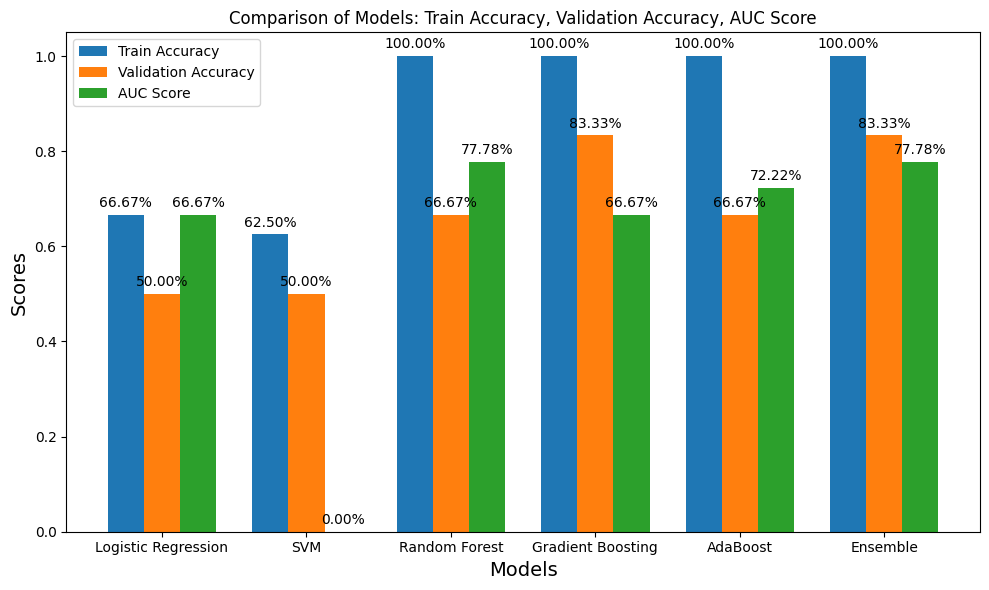

--- Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

          -1       0.50      0.33      0.40         3
           1       0.50      0.67      0.57         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6

--- Classification Report for SVM ---
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         3
           1       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6

--- Classification Report for Random Forest ---
              precision    recall  f1-score   support

          -1       1.00      0.33      0.50         3
           1       0.60      1.00      0.75         3

    accuracy                           0.6

In [14]:
# Initialize lists to store metrics
models = ['Logistic Regression', 'SVM', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'Ensemble']
train_accuracies = []
valid_accuracies = []
auc_scores = []
class_reports = []

# Loop over models
for model, name in zip([logreg, svm, rf, gb, ab, ensemble], models):
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Training metrics
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Accuracy and AUC calculation
    train_acc = accuracy_score(y_train, y_train_pred)
    valid_acc = accuracy_score(y_test, y_test_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    # Store the metrics
    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)
    auc_scores.append(auc)
    
    # Classification report
    class_reports.append(classification_report(y_test, y_test_pred, zero_division=0))


# Find models with the highest AUC score
max_auc_value = max(auc_scores)
max_auc_models = [models[i] for i, auc in enumerate(auc_scores) if auc == max_auc_value]

# Find the model with the highest validation accuracy among those with the highest AUC score
highest_valid_acc = -1  # Initialize with a very low value
recommended_model = None
for model in max_auc_models:
    idx = models.index(model)  # Get the index of the model
    if valid_accuracies[idx] > highest_valid_acc:
        highest_valid_acc = valid_accuracies[idx]
        recommended_model = model
print(f"Highly Recommended Model: {recommended_model}") # AUC Score 높은것들 중 Validation Accuracy 높은 model.


# Create a grouped bar chart to compare the metrics
x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars for each metric
bars1 = ax.bar(x - width, train_accuracies, width, label='Train Accuracy')
bars2 = ax.bar(x, valid_accuracies, width, label='Validation Accuracy')
bars3 = ax.bar(x + width, auc_scores, width, label='AUC Score')

# Add some text for labels, title, and custom x-axis tick labels
ax.set_xlabel('Models', fontsize = 14)
ax.set_ylabel('Scores', fontsize = 14)
ax.set_title('Comparison of Models: Train Accuracy, Validation Accuracy, AUC Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Annotate each bar with its value (percentage)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()  # the height of the bar
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
            height + 0.01,  # y position (just above the bar)
            f'{height * 100:.2f}%',  # label as percentage
            ha='center',  # horizontal alignment
            va='bottom',  # vertical alignment (positioning the text above the bar)
            fontsize=10
        )

# Display the plot
plt.tight_layout()
plt.show()

# Now, print classification reports after showing the graph
for name, report in zip(models, class_reports):
    print(f"--- Classification Report for {name} ---")
    # Add zero_division=0 or zero_division=1 to avoid warnings
    print(report)
